# Predictions for generated recipes

Defines the generated candidate recipes, collects ground truths, and compares them against forward-model predictions.

In [1]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model
from labcompass.constants import DataFields
import torch.nn.functional as F

## Initialize recipes to predict for 

In [2]:
recipes_to_predict = np.array([[0, 0, 0, 83.2, 0, 0, 121.5, 0, 0, 0, 20, 14, 0, 0, 0],
                               [0.6, 2.1, 2.7, 0, 0, 0.8, 2.6, 1.4, 0, 24.9, 20, 12, 0, 0, 2.1], 
                               [4.1, 2.2, 0.6, 0, 0, 1.2, 1.1, 0.4, 0, 4.6, 20, 12, 0, 1.1, 0.6]
                              ])
recipes_to_predict = np.log1p(recipes_to_predict)

recipes_to_predict_t = torch.from_numpy(recipes_to_predict).unsqueeze(0).repeat(5000, 1, 1)

In [3]:
recipes_to_predict

array([[0.        , 0.        , 0.        , 4.43319492, 0.        ,
        0.        , 4.80811103, 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 , 0.        , 0.        , 0.        ],
       [0.47000363, 1.13140211, 1.30833282, 0.        , 0.        ,
        0.58778666, 1.28093385, 0.87546874, 0.        , 3.25424297,
        3.04452244, 2.56494936, 0.        , 0.        , 1.13140211],
       [1.62924054, 1.16315081, 0.47000363, 0.        , 0.        ,
        0.78845736, 0.74193734, 0.33647224, 0.        , 1.7227666 ,
        3.04452244, 2.56494936, 0.        , 0.74193734, 0.47000363]])

# Collect ground truths 

In [4]:
os.environ["REPO_ROOT"] = os.path.abspath("../../..")

with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                     overrides=[
                        "paths=loop4_replicate",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [5]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [6]:
train_adata_g = target_prediction_model.train_data.adata

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [7]:
condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
recipes_to_predict_t = recipes_to_predict_t.to(forward_model.device).float()

batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: recipes_to_predict_t}}
forward_out = forward_model.predict(
    batch_dict,
    no_grad=True,
    fix_noise=False,
    num_time_steps=100
)
# Collect predictions 
y_pred = forward_out["target_prediction_data"]["cell_type"].view(recipes_to_predict_t.shape[0], 
                                                                 recipes_to_predict_t.shape[1], 
                                                                 len(classes))  
y_pred_softmax = F.softmax(y_pred, dim=-1)

In [8]:
y_pred_pred = y_pred_softmax.argmax(-1).cpu().numpy()
pred_classes = classes[y_pred_pred]

In [9]:
pred_r1 = pd.DataFrame(pred_classes[:,0])
pred_r2 = pd.DataFrame(pred_classes[:,1])
pred_r3 = pd.DataFrame(pred_classes[:,2])

In [10]:
pred_r1_prop = pd.DataFrame(pred_r1.value_counts() /  pred_r1.value_counts().sum())
pred_r1_prop["Recipe"] = "Recipe 1"

In [11]:
pred_r2_prop = pd.DataFrame(pred_r2.value_counts() /  pred_r2.value_counts().sum())
pred_r2_prop["Recipe"] = "Recipe 2"

In [12]:
pred_r3_prop = pd.DataFrame(pred_r3.value_counts() /  pred_r3.value_counts().sum())
pred_r3_prop["Recipe"] = "Recipe 3"

In [13]:
pred_prop_tot = pd.concat([pred_r1_prop, pred_r2_prop, pred_r3_prop], axis=0)
pred_prop_tot = pred_prop_tot.reset_index(drop=False)
pred_prop_tot.columns = ["cell_type", "prop", "recipe"]

/tmp/ipykernel_3155861/2814242391.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=13)
/tmp/ipykernel_3155861/2814242391.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)


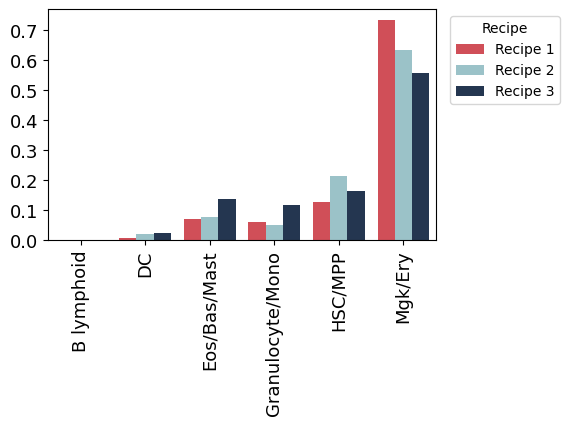

In [14]:

# Map fine-grained cell types to coarser lineage categories
# Adjust these groupings to match your biological interpretation
coarse_map = {
    # Stem / progenitor
    "HSCs": "HSC/MPP",
    "MPP": "HSC/MPP",
    "earlyMPP": "HSC/MPP",
    "Early_GMP": "HSC/MPP",
    "LMPP-CLP": "HSC/MPP",
    "MLP": "HSC/MPP",
    "CyclingPro1": "HSC/MPP",
    "CyclingPro2": "HSC/MPP",

    # Megakaryocyte-Erythroid lineage
    "late_MgkPro": "Mgk/Ery",
    "MgKEryPro1": "Mgk/Ery",   # capital K
    "MgKEryPro2": "Mgk/Ery",   # capital K
    "MPP_MgkEry": "Mgk/Ery",
    "EryPro": "Mgk/Ery",

    # Eosinophil/Basophil/Mast
    "EosBasMast1": "Eos/Bas/Mast",
    "EosBasMast2": "Eos/Bas/Mast",
    "EosBasMast3": "Eos/Bas/Mast",

    # Granulocyte/Monocyte (myeloid)
    "GMP-Neutro": "Granulocyte/Mono",
    "GMP_cycling": "Granulocyte/Mono",
    "CD16Mono": "Granulocyte/Mono",
    "CD14Mono": "Granulocyte/Mono",

    # Dendritic cells
    "pre_cDC1": "DC",
    "pre_cDC2": "DC",

    # B lymphoid
    "preProB": "B lymphoid",
    "ProB": "B lymphoid",
}

# Apply mapping (anything not in the dict keeps its original label — check for stragglers)
pred_prop_tot["cell_type_coarse"] = pred_prop_tot["cell_type"].map(coarse_map).fillna(pred_prop_tot["cell_type"])

# Sum proportions within each coarse category, per recipe
pred_prop_coarse = (
    pred_prop_tot
    .groupby(["cell_type_coarse", "recipe"], as_index=False)["prop"]
    .sum()
)

# Custom palette mapped to recipe/cluster
custom_palette = {
    "Recipe 1": "#E63946",
    "Recipe 2": "#94C7CF",
    "Recipe 3": "#1D3557",
}

fig, ax = plt.subplots(figsize=(5, 3))

sns.barplot(
    data=pred_prop_coarse,
    x="cell_type_coarse",
    y="prop",
    hue="recipe",
    palette=custom_palette,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=13)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("", fontsize=12)
ax.set_title("", fontsize=14)
ax.legend(title="Recipe", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.savefig("../plots/cell_type_proportions.svg", bbox_inches="tight")
plt.show()